# Getting started: fit a Hopfield system to pancreatic endocrinogenesis

scHopfield fits a continuous Hopfield system to single-cell data,

$$\frac{dx}{dt} = W\,\sigma(x) - \Gamma x + I,$$

where $x$ is smoothed expression, $\sigma$ is a per-gene saturating Hill activation, $W$ is a
gene-by-gene interaction matrix restricted to transcription-factor regulators, $\Gamma$ is a
diagonal matrix of degradation rates, and $I$ is a bias. One such system is fit per cell type,
from an observed RNA velocity field.

This tutorial takes the pancreatic endocrinogenesis dataset from a single scVelo call all the
way to a fitted system, and saves a checkpoint that the other tutorials load. Nothing here
needs data that is not downloaded by the code you are reading.

**What you will do**

1. Download the data and run the standard scVelo preprocessing and steady-state velocity.
2. Map the result onto the three fields scHopfield reads.
3. Fit a saturating activation function per gene.
4. Build a transcription-factor scaffold from a base regulatory network.
5. Fit $W$, $\Gamma$ and $I$ per cell type.
6. Check that the fitted system reproduces the velocity it was fit to.
7. Save the fitted model.

**Requirements.** scHopfield with the velocity extra (`pip install 'scHopfield[velocity]'`),
which brings in scVelo. A CUDA GPU is optional but recommended: the fit is the one expensive
step and it runs about an order of magnitude faster on a GPU than on a CPU.

**Runtime.** About three and a half minutes end to end on an RTX 3090, of which the interaction
fit is roughly two and a half minutes. The exact timings this run produced are printed as you go.

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import torch

import scHopfield as sch

scv.settings.verbosity = 1
sc.settings.verbosity = 1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("scHopfield", sch.__version__)
print("scvelo    ", scv.__version__)
print("scanpy    ", sc.__version__)
print("device    ", DEVICE)

scHopfield 1.0.0
scvelo     0.3.4
scanpy     1.12.2
device     cuda


## 1. The data

Pancreatic endocrinogenesis at embryonic day 15.5 (Bastidas-Ponce et al. 2019). scVelo
downloads the object on first use and reads the cached copy afterwards, so this notebook
has no data prerequisite of its own.

Ductal cells give rise to Ngn3-low and then Ngn3-high endocrine progenitors, which pass
through a pre-endocrine state and commit to one of four hormone-producing fates: alpha, beta,
delta and epsilon. That branching structure is what the fitted system has to represent.

In [2]:
adata = scv.datasets.pancreas()
print(adata)
print()
print(adata.obs["clusters"].value_counts().to_string())

100%|██████████| 50.0M/50.0M [00:01<00:00, 39.4MB/s]


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70


## 2. Preprocessing and a first velocity estimate

scHopfield does not estimate RNA velocity. It consumes one, and here that is scVelo's
steady-state estimate. The recipe below is the one the published pancreas fit was run with:
filter genes by shared counts, normalize per cell, log-transform, keep the 2000 most variable
genes, compute first- and second-order moments over a 30-neighbor graph, and estimate velocity
in `steady_state` mode.

These values are written out rather than left to library defaults, because a default that moves
later would silently change the object this notebook produces.

In [3]:
t0 = time.time()

MIN_SHARED_COUNTS = 20
N_TOP_GENES = 2000
N_PCS = 30
N_NEIGHBORS = 30

scv.pp.filter_genes(adata, min_shared_counts=MIN_SHARED_COUNTS)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_GENES)
adata = adata[:, adata.var["highly_variable"]].copy()
scv.pp.moments(adata, n_pcs=N_PCS, n_neighbors=N_NEIGHBORS)
scv.tl.velocity(adata, mode="steady_state")

print(f"\npreprocessing: {time.time() - t0:.1f} s")
print(adata.shape)

/tmp/ipykernel_565751/2756536802.py:13: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=N_PCS, n_neighbors=N_NEIGHBORS)
.../site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(



preprocessing: 11.3 s
(3696, 2000)


## 3. What scHopfield reads

Three fields, and no more:

| Field | Meaning |
| :-- | :-- |
| `adata.layers['Ms']` | smoothed spliced expression, the state $x$ |
| `adata.layers['velocity_S']` | the observed velocity $dx/dt$ the fit is matched against |
| `adata.var['gamma']` | a per-gene degradation rate, used to initialize $\Gamma$ |

scVelo writes the last two under different names, so they are copied across. Genes whose
steady-state fit did not produce a usable degradation rate, or whose velocity is not finite in
every cell, are dropped here rather than allowed to reach the optimizer, where a single
non-finite entry turns the whole loss into `NaN`.

In [4]:
adata.layers["velocity_S"] = adata.layers["velocity"]
adata.var["gamma"] = adata.var["velocity_gamma"].astype(np.float32)

finite_gamma = np.isfinite(adata.var["gamma"].values)
vel = np.asarray(adata.layers["velocity_S"])
finite_vel = np.isfinite(vel).all(axis=0)
keep = finite_gamma & finite_vel & (adata.var["gamma"].values > 0)

print(f"genes with a usable steady-state fit: {keep.sum()} / {adata.n_vars}")
adata = adata[:, keep].copy()
adata.shape

genes with a usable steady-state fit: 2000 / 2000


(3696, 2000)

## 4. Choosing the genes to model

The model is dense in the genes it carries, so the gene set is a real choice. We rank by
velocity magnitude and keep the top 2000, which is the number the published fits use. Here
every surviving gene is kept, because the preceding steps land exactly at that number; the call is
left in because it is the step you would need on a larger object.

`scHopfield_used` marks the genes the model is fit on. Several later functions read it, and
building the scaffold in the next section depends on it.

In [5]:
N_GENES = 2000

sub = (sch.workflows.select_top_velocity_genes(adata, N_GENES)
       if N_GENES < adata.n_vars else adata.copy())
sub.var["scHopfield_used"] = True
print(sub.shape)

(3696, 2000)


## 5. Gene activation functions

$\sigma$ is fit per gene as a Hill function of that gene's own expression,

$$\sigma_g(x_g) = \frac{x_g^{n_g}}{x_g^{n_g} + \theta_g^{n_g}},$$

with a threshold $\theta_g$, an exponent $n_g$ and an offset. The fit is made against the
gene's empirical cumulative distribution over cells rather than against its velocity, so the
activation is determined by the expression distribution alone and is not free to absorb
dynamics that $W$ should be explaining.

Two settings matter and both are the published configuration, which is also what the package
now defaults to:

- `n_max=20` caps the Hill exponent. The cap has to sit well above a typical fit, because
  sharply switching genes are otherwise clipped at the ceiling and fit badly.
- `bimodal=True` fits a two-component activation. Many genes are expressed in two distinct
  regimes rather than one, and forcing a single Hill onto them costs accuracy where the
  switch actually happens.

`compute_sigmoid` then evaluates the fitted activation for every cell and stores it as a layer,
which is what the optimizer consumes.

In [6]:
t0 = time.time()
sch.pp.fit_all_sigmoids(sub, spliced_key="Ms", n_max=20, bimodal=True)
sch.pp.compute_sigmoid(sub, spliced_key="Ms")
print(f"\nactivation fits: {time.time() - t0:.1f} s")

print(f"\nHill exponent:  median {np.nanmedian(sub.var['sigmoid_exponent']):.2f}, "
      f"{(sub.var['sigmoid_exponent'] >= 19.9).sum()} genes at the ceiling")
print(f"fit error (MSE): median {np.nanmedian(sub.var['sigmoid_mse']):.4f}")


activation fits: 34.4 s

Hill exponent:  median 2.96, 0 genes at the ceiling
fit error (MSE): median 0.0003


A fitted activation, drawn against the gene's own expression. The step is the switch: below the
threshold the gene contributes almost nothing to any target, above it the contribution
saturates. Saturation is what keeps the system bounded, and it is the reason the model can carry
several stable states rather than one.

showing Neurog3


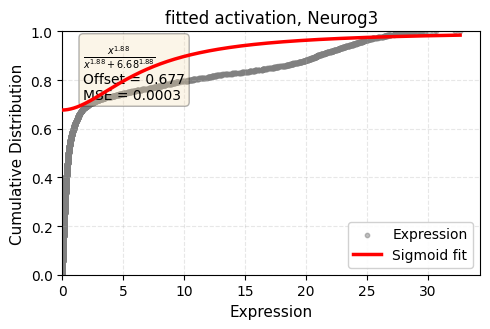

In [7]:
CANDIDATES = ["Neurog3", "Pdx1", "Neurod1", "Sox9", "Arx", "Pax4", "Ins1", "Gcg"]
gene = next(g for g in CANDIDATES if g in sub.var_names)
print(f"showing {gene}")

fig, ax = plt.subplots(figsize=(5, 3.4))
sch.pl.plot_sigmoid_fit(sub, gene, spliced_key="Ms", ax=ax)
ax.set_title(f"fitted activation, {gene}")
fig.tight_layout()
plt.show()

## 6. The structural scaffold

Left free, $W$ has as many parameters as there are gene pairs, and single-cell data does not
determine them. scHopfield restricts it two ways.

First, only transcription factors are allowed to regulate: every column of $W$ that does not
belong to a TF is held at zero. Second, TF-to-target pairs that are not supported by an
independent base regulatory network are penalized rather than forbidden, so the data can still
add an edge if it pays for it, but the prior is where the fit starts.

The base network here is a mouse scATAC atlas, fetched and cached on first use. It is a
third-party table distributed under its own terms, which is why the package downloads it from a
pinned source instead of shipping a copy. `build_scaffold` intersects it with the genes we are
modeling and reports how much structure survived.

In [8]:
t0 = time.time()
base = sch.fetch_base_grn("mouse")
scaffold, n_tfs, n_edges = sch.inf.build_scaffold(sub, base, return_stats=True)
print(f"\nscaffold: {n_tfs} TFs, {n_edges} edges, covering "
      f"{n_edges / (n_tfs * sub.n_vars):.1%} of the possible TF-to-gene pairs")
print(f"scaffold: {time.time() - t0:.1f} s")


scaffold: 105 TFs, 87632 edges, covering 41.7% of the possible TF-to-gene pairs
scaffold: 6.8 s


## 7. Fitting the interaction matrices

One system per cell type, plus a single system fit on all cells together, which the next
section uses as the comparison. The objective matches the model's velocity to the observed one
while penalizing off-scaffold edges and a dense bias.

Every keyword below is the package default, and the defaults are the published configuration,
so this call is the one the paper's pancreas fit was run with. They are written out anyway,
because a tutorial that hides its settings teaches nothing about them:

- `n_epochs=600`, `batch_size=128`, `learning_rate=0.1` with a plateau scheduler.
- `reconstruction_regularization=100` weights matching the observed velocity.
- `bias_regularization=1` with an L1 penalty keeps $I$ sparse, so the bias cannot quietly
  absorb the dynamics that $W$ should explain.
- `only_TFs=True` zeroes the gene-to-gene block of $W$; off-scaffold TF edges stay penalized
  rather than forbidden.
- `include_neighbors=True` with `neighbor_fraction=0.2` lets each cell type's fit see a
  fraction of its neighbors in the graph, which stabilizes small clusters.
- `refit_gamma=True` lets the degradation rates move off their steady-state initialization,
  with `gamma_min=0.01` as a hard floor and `boundedness_lambda=0.1` weighting a far-field
  penalty. Together these keep the fitted system's trajectories bounded.
- `seed=0` makes the fit reproducible.

In [9]:
t0 = time.time()
sch.inf.fit_interactions(
    sub,
    cluster_key="clusters",
    w_scaffold=scaffold.values.T,
    device=DEVICE,
    n_epochs=600,
    batch_size=128,
    learning_rate=0.1,
    reconstruction_regularization=100,
    bias_regularization=1,
    bias_penalty="l1",
    refit_gamma=True,
    use_plateau_scheduler=True,
    plateau_patience=100,
    plateau_factor=0.1,
    drop_last=True,
    include_neighbors=True,
    neighbor_fraction=0.2,
    only_TFs=True,
    boundedness_lambda=0.1,
    gamma_min=0.01,
    seed=0,
)
fit_seconds = time.time() - t0
print(f"\ninteraction fit: {fit_seconds:.1f} s on {DEVICE}")
print("fitted systems:", sorted(k[2:] for k in sub.varp if k.startswith("W_")))

Inferring interaction matrix W and bias vector I for cluster Pre-endocrine
  Including 502 neighboring cells (592 cluster + 502 neighbors = 1094 total)


[Epoch 1/600] Total Loss: 5160.275909, Reconstruction Loss: 257.059448, LR: 1.00e-01, Batch size: 128


[Epoch 101/600] Total Loss: 1632.909058, Reconstruction Loss: 4.905929, LR: 1.00e-01, Batch size: 128


[Epoch 201/600] Total Loss: 171.340288, Reconstruction Loss: 3.135684, LR: 1.00e-02, Batch size: 128


[Epoch 301/600] Total Loss: 17.617363, Reconstruction Loss: 3.118370, LR: 1.00e-03, Batch size: 128


...

[Epoch 301/600] Total Loss: 20.306582, Reconstruction Loss: 5.222345, LR: 1.00e-03, Batch size: 128


[Epoch 401/600] Total Loss: 6.673807, Reconstruction Loss: 5.230718, LR: 1.00e-04, Batch size: 128


[Epoch 501/600] Total Loss: 5.348038, Reconstruction Loss: 5.202729, LR: 1.00e-05, Batch size: 128


Training Epochs: 100%|██████████| 600/600 [00:54<00:00, 11.01it/s]


[Epoch 600/600] Total Loss: 5.190552, Reconstruction Loss: 5.166382, LR: 1.00e-06, Batch size: 128

interaction fit: 154.9 s on cuda
fitted systems: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']


## 8. Does the fitted system reproduce the velocity?

The check is the model equation itself: evaluate $W\sigma(x) - \Gamma x + I$ for every cell
under its own cell type's parameters, and compare the result with the velocity the fit was
given, cell by cell, as a cosine similarity.

The comparison that matters is against the same model fit once on all cells together. If one
global system did as well, the cell-type-specific systems would be an expensive way to say
nothing. Both arms are in-sample, so this measures fit quality rather than generalization, and
the cell-type-specific arm carries more parameters. The point of the comparison is direction and
size, not a claim about held-out data.

In [10]:
def row_cosine(A, B):
    n = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    return (A * B).sum(1) / np.where(n > 0, n, np.nan)


V = np.asarray(sub.layers["velocity_S"])
x = np.asarray(sub.layers["Ms"])
sig = np.asarray(sub.layers["sigmoid"])

# Cell-type-specific field: every cell under its own cell type's parameters.
pred_ct = sch.tl.compute_reconstructed_velocity(sub, cluster_key="clusters")

# One global field: the same equation with the single all-cells system.
W_all = np.asarray(sub.varp["W_all"])
I_all = np.asarray(sub.var["I_all"])
g_all = np.asarray(sub.var["gamma_all"])
pred_all = sig @ W_all.T + I_all - g_all * x

cos_ct = row_cosine(pred_ct, V)
cos_all = row_cosine(pred_all, V)

print(f"median per-cell velocity cosine")
print(f"  cell-type-specific : {np.nanmedian(cos_ct):.4f}")
print(f"  one global system  : {np.nanmedian(cos_all):.4f}")
print(f"  gain               : {np.nanmedian(cos_ct) - np.nanmedian(cos_all):+.4f}")

median per-cell velocity cosine
  cell-type-specific : 0.9615
  one global system  : 0.9282
  gain               : +0.0333


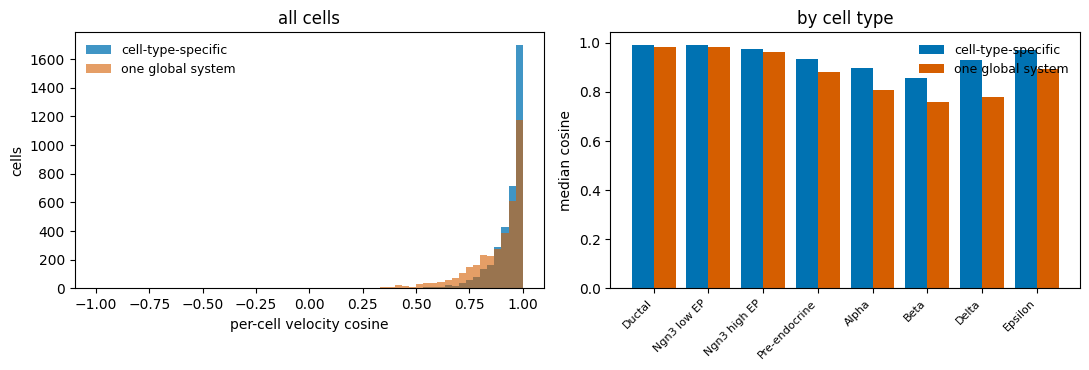

In [11]:
order = ["Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
         "Alpha", "Beta", "Delta", "Epsilon"]
lab = sub.obs["clusters"].astype(str).values

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(cos_ct[np.isfinite(cos_ct)], bins=60, range=(-1, 1),
             color="#0072B2", alpha=0.75, label="cell-type-specific")
axes[0].hist(cos_all[np.isfinite(cos_all)], bins=60, range=(-1, 1),
             color="#D55E00", alpha=0.6, label="one global system")
axes[0].set_xlabel("per-cell velocity cosine")
axes[0].set_ylabel("cells")
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_title("all cells")

meds_ct = [np.nanmedian(cos_ct[lab == c]) for c in order]
meds_all = [np.nanmedian(cos_all[lab == c]) for c in order]
xs = np.arange(len(order))
axes[1].bar(xs - 0.2, meds_ct, 0.4, color="#0072B2", label="cell-type-specific")
axes[1].bar(xs + 0.2, meds_all, 0.4, color="#D55E00", label="one global system")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(order, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("median cosine")
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].legend(frameon=False, fontsize=9)
axes[1].set_title("by cell type")

fig.tight_layout()
plt.show()

## 9. Saving the fitted model

`save_model` writes the parameters that define the system: the interaction matrices, the bias
and degradation vectors, the activation parameters and the gene mask. It does not write the
cell-level data, which keeps the file small and means it is a model rather than a copy of the
experiment.

The rest of the tutorials load this file. Each of them rebuilds the prepared object from
sections 1 to 5, which costs well under a minute on a CPU, and then restores the fitted network
from this checkpoint instead of repeating the fit. That is the whole reason the checkpoint is
worth saving: it takes the one step that wants a GPU out of every later tutorial.

The activation is written in full: both Hill components of every gene, the weight that mixes
them, and a record of which fit mode produced them. That is what lets a later notebook call
`compute_sigmoid` straight after `load_model` and get the activation this fit used, rather than a
single Hill curve standing in for it. The cell after the save checks that against the file rather
than asserting it.

In [12]:
sch.tl.save_model(sub, "pancreas_fitted.h5sch", overwrite=True)
print(f"{os.path.getsize('pancreas_fitted.h5sch') / 1e6:.1f} MB")

Model saved to 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000
7.4 MB


In [13]:
# What the file alone restores. Strip every activation parameter from a copy, load the
# checkpoint into it, and compare the rebuilt activation against the one fitted above.
probe = sub.copy()
sigmoid_cols = sorted(c for c in probe.var.columns if c.startswith("sigmoid_"))
probe.var.drop(columns=sigmoid_cols, inplace=True)
probe.uns["scHopfield"].pop("sigmoid_bimodal", None)

probe = sch.tl.load_model(probe, "pancreas_fitted.h5sch", overwrite=True)
sch.pp.compute_sigmoid(probe, spliced_key="Ms")

restored = sorted(c for c in probe.var.columns if c.startswith("sigmoid_"))
drift = np.abs(np.asarray(probe.layers["sigmoid"]) - np.asarray(sub.layers["sigmoid"])).max()

print("activation columns restored from the file:", ", ".join(restored))
print(f"fit mode recorded in the file: bimodal={probe.uns['scHopfield']['sigmoid_bimodal']}")
print(f"largest difference in the rebuilt activation: {drift:.3g}")
assert restored == sigmoid_cols and drift == 0

Model loaded from 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000


activation columns restored from the file: sigmoid_exponent, sigmoid_exponent2, sigmoid_mix, sigmoid_mse, sigmoid_offset, sigmoid_threshold, sigmoid_threshold2
fit mode recorded in the file: bimodal=True
largest difference in the rebuilt activation: 0


## 10. The same run in one call

Everything above is also available as a single call, which is the right entry point once you
know what the steps are and want to run the pipeline on your own object:

```python
import scHopfield as sch

adata = sch.run_pipeline(
    adata,
    cluster_key="clusters",
    prepare=True,        # velocity and activation preprocessing
    n_top_genes=2000,
    device="cuda",
    seed=0,
)
```

`run_pipeline` also runs the downstream analyses that the next tutorials do step by step. It is
not executed here, because doing so would repeat the fit you just paid for.

## Where to go next

- **Reading the fitted system** derives the energy landscape, the Jacobian stability structure
  and the regulatory network from this one fit, without fitting anything further.
- **Single-gene knockouts** uses the fitted system to extrapolate to perturbed states.
- **Why the structural scaffold matters** refits the interaction matrix without the scaffold and
  shows what is lost.